In [1]:
from math import radians, sin, cos, sqrt, atan2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer

# Data Collection

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhruvb2028/credit-card-fraud-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-fraud-dataset' dataset.
Path to dataset files: /kaggle/input/credit-card-fraud-dataset


# Data Inspection

In [3]:
df = pd.read_csv(path + r'/credit_card_frauds.csv')
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [4]:
# Checking for null values
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
city,0
state,0
lat,0
long,0
city_pop,0
job,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

Need to handle time data and lat/long data

# Feature Engineering

### Date and time features

In [6]:
# Changing trans date to datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_date_trans_time'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 339607 entries, 0 to 339606
Series name: trans_date_trans_time
Non-Null Count   Dtype         
--------------   -----         
339607 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.6 MB


In [7]:
# Changing dob date to datetime
df['dob'] = pd.to_datetime(df['dob'])
df['dob'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 339607 entries, 0 to 339606
Series name: dob
Non-Null Count   Dtype         
--------------   -----         
339607 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.6 MB


In [8]:
# Creating separate columns for trans time
df['purch_hour'] = df['trans_date_trans_time'].dt.hour
df['purch_day'] = df['trans_date_trans_time'].dt.day
df['purch_month'] = df['trans_date_trans_time'].dt.month

In [9]:
# Creating age column
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days // 365).astype('int')
df[['age', 'trans_date_trans_time', 'dob']].head()

,age,trans_date_trans_time,dob
0,40,2019-01-01 00:00:44,1978-06-21
1,56,2019-01-01 00:00:51,1962-01-19
2,73,2019-01-01 00:07:27,1945-12-21
3,51,2019-01-01 00:09:03,1967-08-30
4,51,2019-01-01 00:21:32,1967-08-02


### Geographic features

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [11]:
df['merchant_buyer_dist'] = df.apply(
    lambda x: haversine(
        x['lat'], x['long'],
        x['merch_lat'], x['merch_long']
    ),
    axis=1
)

# Exploratory Data Analysis

In [12]:
# Frauds by category
df.groupby('category')['is_fraud'].agg(
    fraud_count='sum',
    total='count',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

,fraud_count,total,fraud_rate
category,,,
shopping_net,381,26379,0.014443
grocery_pos,433,32732,0.013229
misc_net,217,16898,0.012842
shopping_pos,187,30329,0.006166
gas_transport,153,35089,0.004360
travel,33,10322,0.003197
misc_pos,62,20024,0.003096
grocery_net,27,11355,0.002378
entertainment,55,24222,0.002271


In [13]:
# Frauds by state
df.groupby('state')['is_fraud'].agg(
    fraud_count='sum',
    total='count',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

,fraud_count,total,fraud_rate
state,,,
AK,50,2963,0.016875
OR,197,26408,0.007460
NE,216,34425,0.006275
CO,115,19766,0.005818
NM,121,23427,0.005165
CA,402,80495,0.004994
MO,262,54904,0.004772
WA,126,27040,0.004660
HI,16,3649,0.004385


In [14]:
# Number of states, 13
df['state'].unique()

array(['WA', 'ID', 'CA', 'NM', 'WY', 'HI', 'NE', 'OR', 'UT', 'AZ', 'CO',
       'MO', 'AK'], dtype=object)

In [15]:
# Frauds by age
df.groupby('age')['is_fraud'].agg(
    fraud_count='sum',
    total='count',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

,fraud_count,total,fraud_rate
age,,,
89,12,280,0.042857
87,15,368,0.040761
22,53,1384,0.038295
73,21,985,0.021320
77,25,1469,0.017018
...,...,...,...
81,0,686,0.000000
88,0,342,0.000000
86,0,34,0.000000


<Axes: >

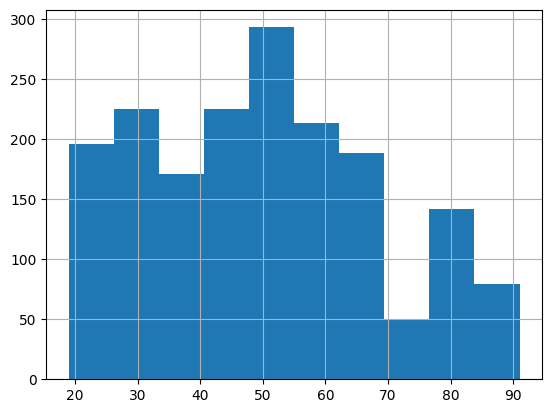

In [16]:
# Fraud by age visual
df['age'][df['is_fraud'] == 1].hist()

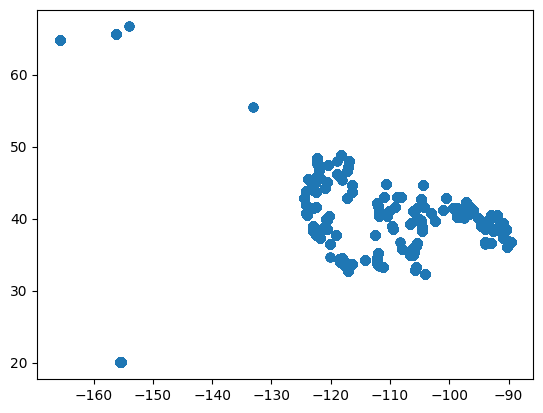

In [17]:
# Visualizing long/lat for buyer locations
plt.scatter(df['long'], df['lat'])
plt.show()

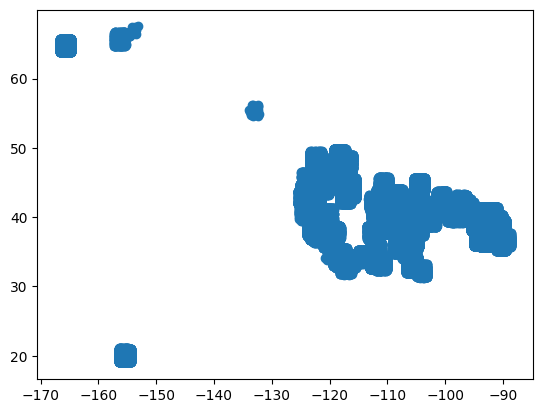

In [18]:
# Visualizing long/lat for merchant locations
plt.scatter(df['merch_long'], df['merch_lat'])
plt.show()

In [19]:
# Preparing fraud column for model
df['is_fraud'] = df['is_fraud'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  339607 non-null  datetime64[ns]
 1   merchant               339607 non-null  object        
 2   category               339607 non-null  object        
 3   amt                    339607 non-null  float64       
 4   city                   339607 non-null  object        
 5   state                  339607 non-null  object        
 6   lat                    339607 non-null  float64       
 7   long                   339607 non-null  float64       
 8   city_pop               339607 non-null  int64         
 9   job                    339607 non-null  object        
 10  dob                    339607 non-null  datetime64[ns]
 11  trans_num              339607 non-null  object        
 12  merch_lat              339607 non-null  floa

In [20]:
# Creating int df for model pipeline
df_int = df.select_dtypes(['float64', 'int64', 'int32'])

df_int.head()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,purch_hour,purch_day,purch_month,age,merchant_buyer_dist
0,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0,0,1,1,40,30.212176
1,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,0,1,1,56,108.206083
2,96.29,41.6125,-122.5258,589,41.657520,-122.230347,0,0,1,1,73,25.059079
3,7.77,32.9396,-105.8189,899,32.863258,-106.520205,0,0,1,1,51,66.021685
4,6.85,43.0172,-111.0292,471,43.753735,-111.454923,0,0,1,1,51,88.830984


In [21]:
# Creating obj df for model pipeline
df_obj = df.select_dtypes('object')
# Dropping unnecessary column
df_obj = df_obj.drop(columns=['trans_num'])
df_obj.head()

,merchant,category,city,state,job
0,"Heller, Gutmann and Zieme",grocery_pos,Orient,WA,Special educational needs teacher
1,Lind-Buckridge,entertainment,Malad City,ID,Nature conservation officer
2,Kiehn Inc,grocery_pos,Grenada,CA,Systems analyst
3,Beier-Hyatt,shopping_pos,High Rolls Mountain Park,NM,Naval architect
4,Bruen-Yost,misc_pos,Freedom,WY,"Education officer, museum"


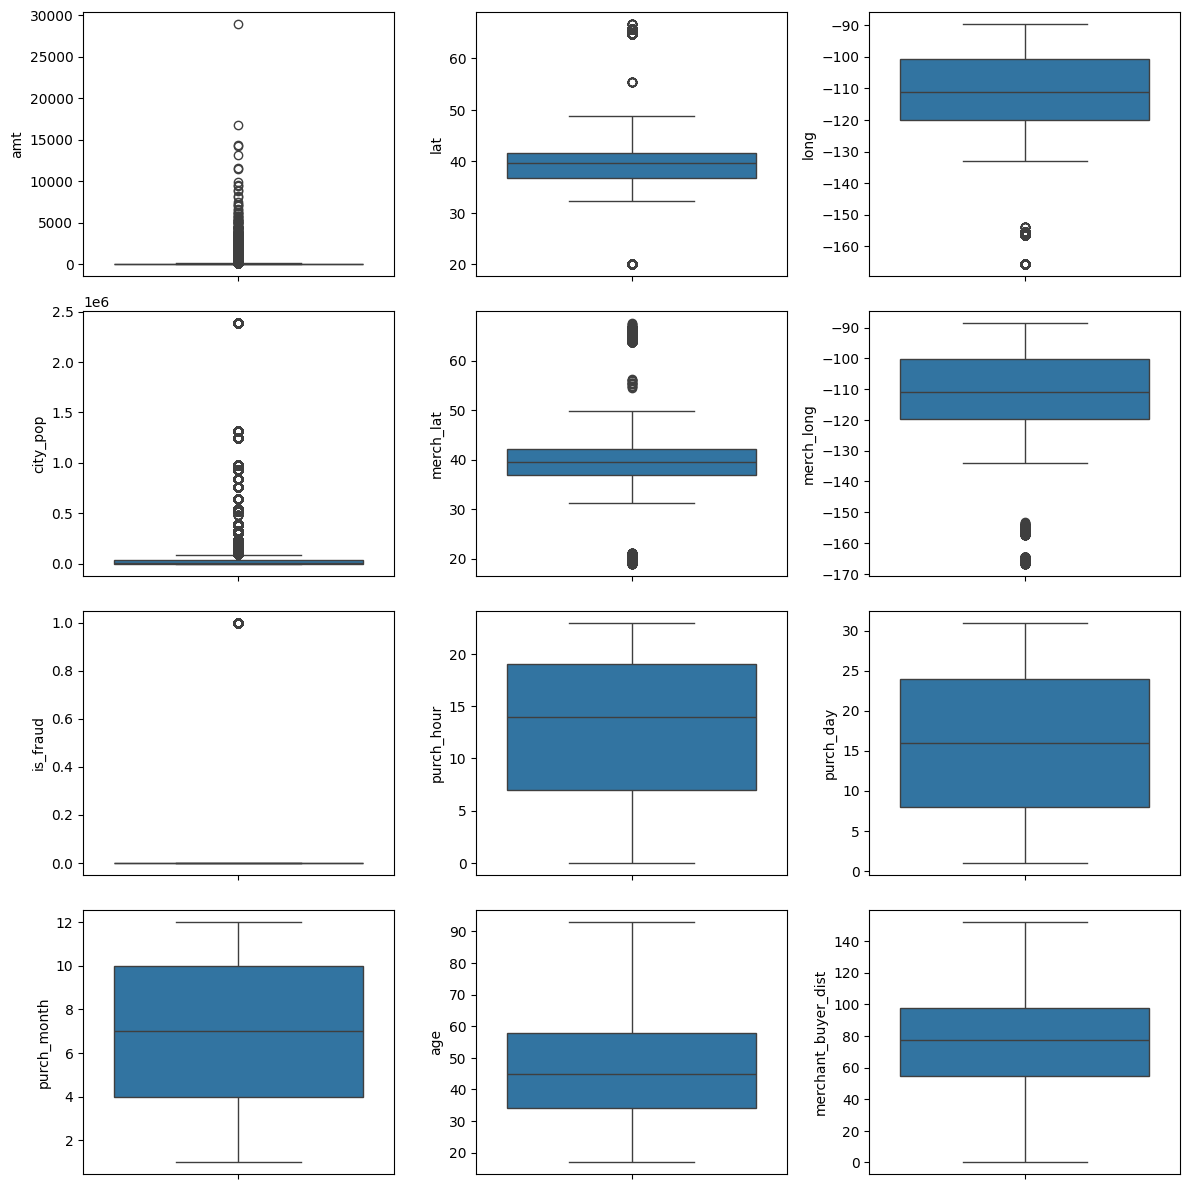

In [22]:
# Boxplots for int features
plt.figure(figsize=(12,12)) # Adjust figure size for better readability with more subplots

n = 1
for column in df_int.columns:
  plt.subplot(4,3,n) # Changed to 4 rows, 3 columns to accommodate 10 plots
  n += 1
  sns.boxplot(df_int[f"{column}"])


plt.tight_layout()
plt.show()

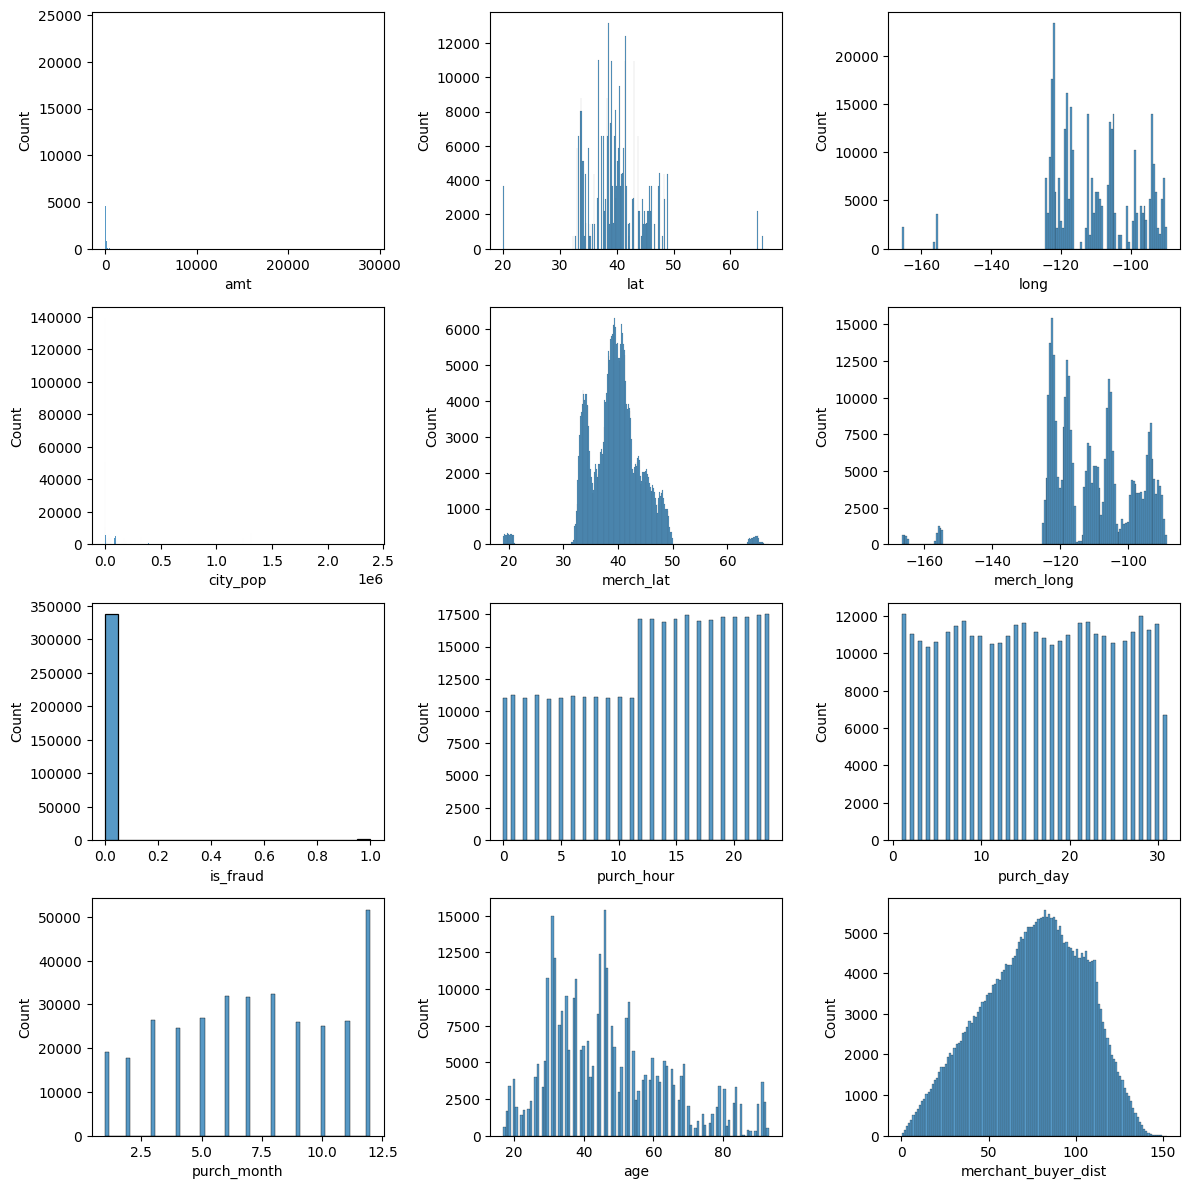

In [23]:
# Distributions for int features
plt.figure(figsize=(12,12)) # Adjust figure size for better readability with more subplots

n = 1
for column in df_int.columns:
  plt.subplot(4,3,n) # Changed to 4 rows, 3 columns to accommodate 10 plots
  n += 1
  sns.histplot(df_int[f"{column}"])


plt.tight_layout()
plt.show()

In [24]:
# Creating df for skewed features getting log transformed
df_log = df[['amt', 'city_pop']]

In [25]:
df_int = df_int.drop(columns='is_fraud')
df_int.head()

,amt,lat,long,city_pop,merch_lat,merch_long,purch_hour,purch_day,purch_month,age,merchant_buyer_dist
0,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0,1,1,40,30.212176
1,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,1,1,56,108.206083
2,96.29,41.6125,-122.5258,589,41.657520,-122.230347,0,1,1,73,25.059079
3,7.77,32.9396,-105.8189,899,32.863258,-106.520205,0,1,1,51,66.021685
4,6.85,43.0172,-111.0292,471,43.753735,-111.454923,0,1,1,51,88.830984


<Axes: >

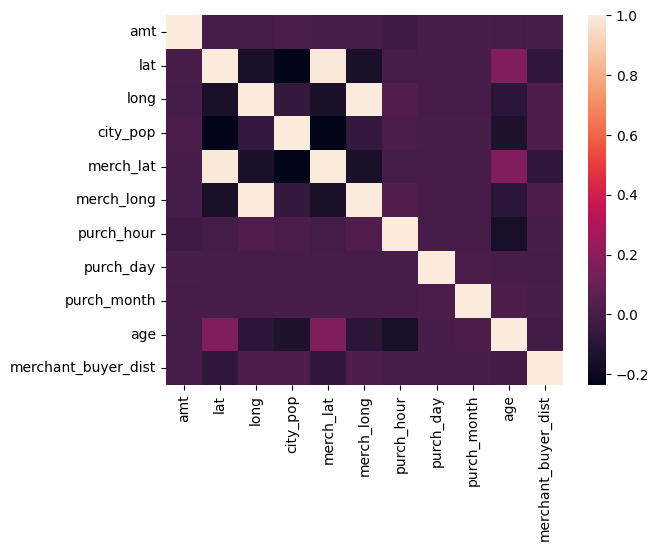

In [26]:
sns.heatmap(df_int.corr())

In [27]:
# Creating list of column names that are of the object dtype
df_olist = df_obj.columns.tolist()
df_olist

['merchant', 'category', 'city', 'state', 'job']

In [28]:
# Creating list of column names that are getting log transformed
df_llist = df_log.columns.tolist()
df_llist

['amt', 'city_pop']

In [29]:
# Creating list of column names that are dtype float and integer
df_ilist = df_int.columns.tolist()
df_ilist

['amt',
 'lat',
 'long',
 'city_pop',
 'merch_lat',
 'merch_long',
 'purch_hour',
 'purch_day',
 'purch_month',
 'age',
 'merchant_buyer_dist']

In [30]:
# Turning object columns into category for model
for category in df_olist:
  category = str(category)
  df[category] = df[category].astype('category')

In [31]:
def evaluate_log(pipeline, X_data, y_data):
  y_pred = pipeline.predict(X_data)
  y_prob = pipeline.predict_proba(X_data)[:, 1]
  print("Accuracy:", accuracy_score(y_data, y_pred))
  print("\nConfusion Matrix:\n", confusion_matrix(y_data, y_pred))
  print("\nClassification Report:\n", classification_report(y_data, y_pred))
  print("\nROC-AUC:", roc_auc_score(y_data, y_prob))
  print("\nMatthews Coefficient:", matthews_corrcoef(y_data, y_pred))

In [32]:
DROP_COLS = [
    "is_fraud",
    "trans_num",
    "trans_date_trans_time"
]

In [33]:
# Create X & y
X = df.drop(columns=DROP_COLS)
y = df["is_fraud"]

#Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline log regression

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

log_transformer = make_pipeline(
    FunctionTransformer(np.log1p, validate=False),
    MinMaxScaler()
)

preprocessor = make_column_transformer(
    (log_transformer, df_llist),
    (MinMaxScaler(), df_ilist), # Scale all values in this column between 0- 1
    (OneHotEncoder(handle_unknown="ignore"), df_olist)
)


# Define the pipeline
base_log = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Train pipeline
base_log.fit(X_train, y_train)

# Test pipeline
y_pred = base_log.predict(X_test)
y_prob = base_log.predict_proba(X_test)[:, 1]

In [35]:
evaluate_log(base_log, X_test, y_test)

Accuracy: 0.9951414858219723

Confusion Matrix:
 [[67542    13]
 [  317    50]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.79      0.14      0.23       367

    accuracy                           1.00     67922
   macro avg       0.89      0.57      0.62     67922
weighted avg       0.99      1.00      0.99     67922


ROC-AUC: 0.866136039723007

Matthews Coefficient: 0.3276256183197878


# Weighted log regression

In [36]:
# Define the pipeline
weight_log = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight={0:1, 1:30}))
])

# Train pipeline
weight_log.fit(X_train, y_train)

# Test pipeline
y_pred = weight_log.predict(X_test)
y_prob = weight_log.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
evaluate_log(weight_log, X_test, y_test)

Accuracy: 0.9862342098289214

Confusion Matrix:
 [[66780   775]
 [  160   207]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     67555
           1       0.21      0.56      0.31       367

    accuracy                           0.99     67922
   macro avg       0.60      0.78      0.65     67922
weighted avg       0.99      0.99      0.99     67922


ROC-AUC: 0.8655451799593307

Matthews Coefficient: 0.33934626182965777


# Model with optimal KBest features

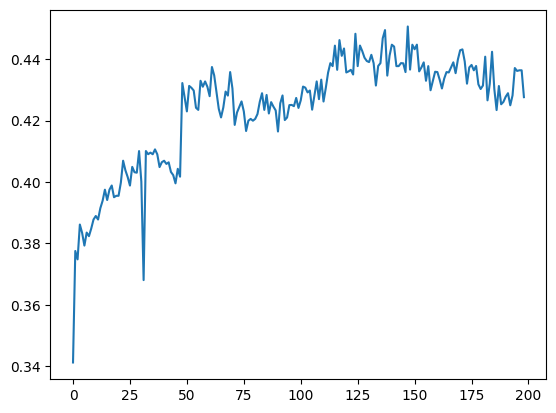

In [38]:
# Finding best k features for optimal matthew's coefficient model
matthews_list = []

for i in range(1, 200):
  selector = SelectKBest(score_func=f_classif, k=i)

  # Define the pipeline
  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('features', selector),
      ('classifier', LogisticRegression(class_weight={0:1, 1:10}))
  ])

  # Train pipeline
  pipeline.fit(X_train, y_train)

  # Test pipeline
  y_pred = pipeline.predict(X_test)
  y_prob = pipeline.predict_proba(X_test)[:, 1]
  matthews_list.append(matthews_corrcoef(y_test, y_pred))

plt.plot(matthews_list)
plt.show()

In [39]:
max_value = matthews_list.index(max(matthews_list))

In [40]:
selector = SelectKBest(score_func=f_classif, k=max_value + 1)

# Define the pipeline
kbest_log = Pipeline([
    ('preprocessor', preprocessor),
    ('features', selector),
    ('classifier', LogisticRegression(class_weight={0:1, 1:15}))
])

# Train pipeline
kbest_log.fit(X_train, y_train)

# Test pipeline
y_pred = kbest_log.predict(X_test)
y_prob = kbest_log.predict_proba(X_test)[:, 1]

In [41]:
evaluate_log(kbest_log, X_test, y_test)

Accuracy: 0.9924619416389387

Confusion Matrix:
 [[67224   331]
 [  181   186]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.36      0.51      0.42       367

    accuracy                           0.99     67922
   macro avg       0.68      0.75      0.71     67922
weighted avg       0.99      0.99      0.99     67922


ROC-AUC: 0.8726460647566006

Matthews Coefficient: 0.42334874116312604


# XGBoost Model

In [42]:
#df_obj = df.copy()

In [43]:
import xgboost
from xgboost import XGBClassifier, plot_importance

# Define the pipeline
xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier())
])

# Train pipeline
xgboost_pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = xgboost_pipeline.predict(X_test)
y_prob = xgboost_pipeline.predict_proba(X_test)[:, 1]

In [44]:
evaluate_log(xgboost_pipeline, X_test, y_test)

Accuracy: 0.9984835546656459

Confusion Matrix:
 [[67531    24]
 [   79   288]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.92      0.78      0.85       367

    accuracy                           1.00     67922
   macro avg       0.96      0.89      0.92     67922
weighted avg       1.00      1.00      1.00     67922


ROC-AUC: 0.9916278934693841

Matthews Coefficient: 0.8503716685597209


# XGBoost with SelectKBest

In [45]:
selector = SelectKBest(score_func=f_classif, k=max_value + 1)

# Define the pipeline
kbest_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('features', selector),
    ('classifier', XGBClassifier())
])

# Train pipeline
kbest_xgb.fit(X_train, y_train)

# Test pipeline
y_pred = kbest_xgb.predict(X_test)
y_prob = kbest_xgb.predict_proba(X_test)[:, 1]

In [46]:
evaluate_log(kbest_xgb, X_test, y_test)

Accuracy: 0.9982038220311534

Confusion Matrix:
 [[67529    26]
 [   96   271]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.91      0.74      0.82       367

    accuracy                           1.00     67922
   macro avg       0.96      0.87      0.91     67922
weighted avg       1.00      1.00      1.00     67922


ROC-AUC: 0.9887265336529707

Matthews Coefficient: 0.8199865458048262


# XGB with categorical True

In [47]:
DROP_COLS = [
    "is_fraud",
    "trans_num",
    "trans_date_trans_time",
    'dob'
]

In [48]:
# Create X & y
X = df.drop(columns=DROP_COLS)
y = df["is_fraud"]

#Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
xgb_cat = XGBClassifier(enable_categorical=True)

xgb_cat.fit(X_train, y_train)

# Test XGBClassifier
y_pred = xgb_cat.predict(X_test)
y_prob = xgb_cat.predict_proba(X_test)[:, 1]

In [50]:
evaluate_log(xgb_cat, X_test, y_test)

Accuracy: 0.9984246635847001

Confusion Matrix:
 [[67522    33]
 [   74   293]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.90      0.80      0.85       367

    accuracy                           1.00     67922
   macro avg       0.95      0.90      0.92     67922
weighted avg       1.00      1.00      1.00     67922


ROC-AUC: 0.9911233293207251

Matthews Coefficient: 0.8463075752446166


# XGBoost with Feature Selection

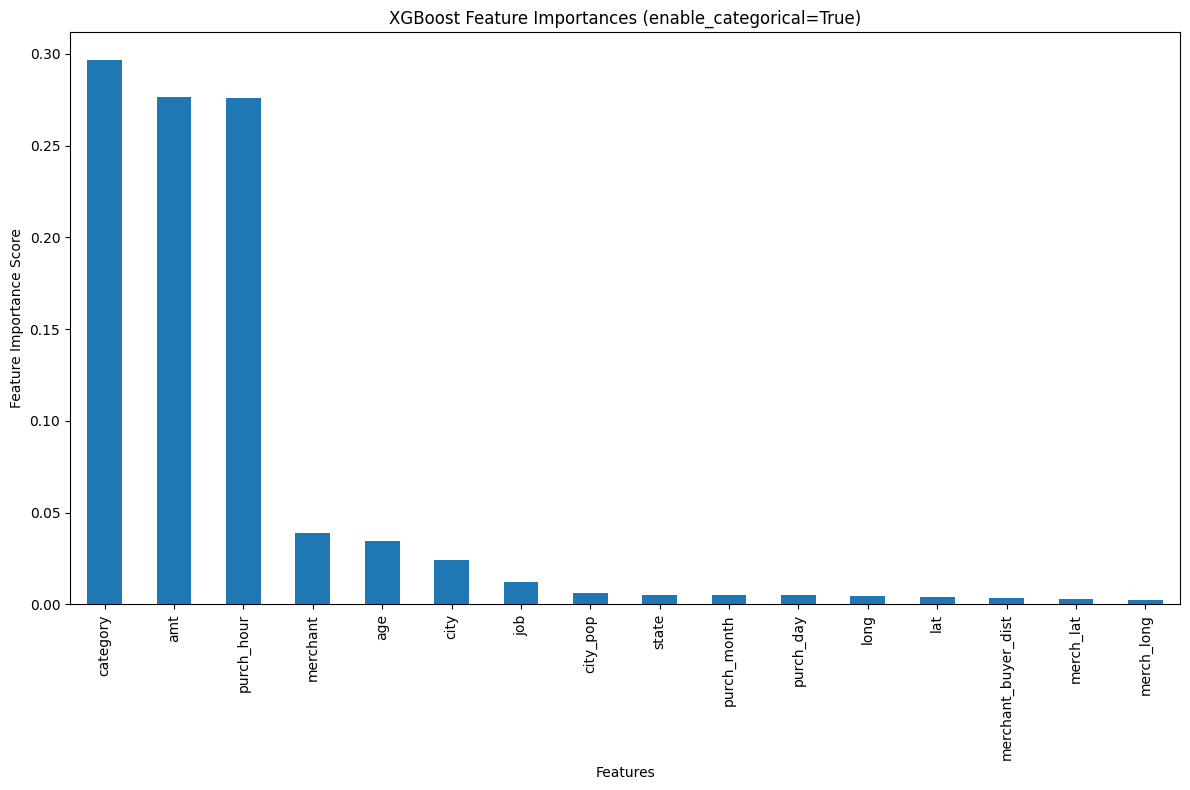

Top 10 features:
category       0.296952
amt            0.276506
purch_hour     0.276260
merchant       0.039149
age            0.034485
city           0.024425
job            0.012226
city_pop       0.006016
state          0.005378
purch_month    0.005358
dtype: float32


In [51]:
# Extract feature importances from xgb_cat
feature_importances = xgb_cat.feature_importances_
feature_names = X_train.columns

# Create a pandas Series for easier sorting and plotting
importance_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 8))
importance_df.plot(kind='bar')
plt.title('XGBoost Feature Importances (enable_categorical=True)')
plt.ylabel('Feature Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Display top 10 features
print("Top 10 features:")
print(importance_df.head(10))

In [52]:
BEST_COLS = importance_df.head(10).index.to_list()
BEST_COLS

['category',
 'amt',
 'purch_hour',
 'merchant',
 'age',
 'city',
 'job',
 'city_pop',
 'state',
 'purch_month']

In [53]:
# Create X & y
X = df[BEST_COLS]
y = df["is_fraud"]

#Build our train and test sets
X_trainb, X_testb, y_trainb, y_testb = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
xgb_bestf = XGBClassifier(enable_categorical=True)

xgb_bestf.fit(X_trainb, y_trainb)

# Test XGBClassifier
y_pred = xgb_bestf.predict(X_testb)
y_prob = xgb_bestf.predict_proba(X_testb)[:, 1]

In [55]:
evaluate_log(xgb_bestf, X_testb, y_testb)

Accuracy: 0.9985277229763553

Confusion Matrix:
 [[67529    26]
 [   74   293]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.92      0.80      0.85       367

    accuracy                           1.00     67922
   macro avg       0.96      0.90      0.93     67922
weighted avg       1.00      1.00      1.00     67922


ROC-AUC: 0.9927914423145375

Matthews Coefficient: 0.8556095011158525


# XGBoost with Hyperparameter Tuning

In [56]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define the model with enable_categorical=True
# Use 'use_label_encoder=False' and 'eval_metric' to suppress warnings from newer XGBoost versions
xgb_model = XGBClassifier(enable_categorical=True, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define a parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize GridSearchCV
# Using 'matthews_corrcoef' as the scoring metric, as it was a key performance indicator
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='matthews_corrcoef',
                           cv=3, verbose=2, n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Fit GridSearchCV on the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best Matthews Coefficient: {grid_search.best_score_}")

# Evaluate the best model found by grid search
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test)
y_prob_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("\nEvaluation of Tuned XGBoost Model:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_tuned))
print("\nMatthews Coefficient:", matthews_corrcoef(y_test, y_pred_tuned))

Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:53:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV completed.

Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best Matthews Coefficient: 0.8560918169988208

Evaluation of Tuned XGBoost Model:
Accuracy: 0.9986307823680104

Confusion Matrix:
 [[67543    12]
 [   81   286]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.96      0.78      0.86       367

    accuracy                           1.00     67922
   macro avg       0.98      0.89      0.93     67922
weighted avg       1.00      1.00      1.00     67922


ROC-AUC: 0.9981043602175399

Matthews Coefficient: 0.864179948188197


# XGBoost with Best Hyperparameters and Best Features

In [57]:
# Define the model with enable_categorical=True
# Use 'use_label_encoder=False' and 'eval_metric' to suppress warnings from newer XGBoost versions
xgb_model = XGBClassifier(enable_categorical=True, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define a parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize GridSearchCV
# Using 'matthews_corrcoef' as the scoring metric, as it was a key performance indicator
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='matthews_corrcoef',
                           cv=3, verbose=2, n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Fit GridSearchCV on the training data
print("Starting GridSearchCV...")
grid_search.fit(X_trainb, y_trainb)
print("GridSearchCV completed.")

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best Matthews Coefficient: {grid_search.best_score_}")

# Evaluate the best model found by grid search
best_xgb_model_b = grid_search.best_estimator_
y_pred_tuned = best_xgb_model_b.predict(X_testb)
y_prob_tuned = best_xgb_model_b.predict_proba(X_testb)[:, 1]

Starting GridSearchCV...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:01:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV completed.

Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best Matthews Coefficient: 0.8508090328439951


In [58]:
evaluate_log(best_xgb_model_b, X_testb, y_testb)

Accuracy: 0.9986013368275375

Confusion Matrix:
 [[67543    12]
 [   83   284]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.96      0.77      0.86       367

    accuracy                           1.00     67922
   macro avg       0.98      0.89      0.93     67922
weighted avg       1.00      1.00      1.00     67922


ROC-AUC: 0.9984496233465636

Matthews Coefficient: 0.8610168468931217


In [ ]:
evaluate_log(xgb_bestf, X_testb, y_testb)
evaluate_log(best_xgb_model_b, X_test, y_test)
evaluate_log(best_xgb_model_b, X_testb, y_testb)

In [ ]:
  print("\nMatthews Coefficient:", matthews_corrcoef(y_data, y_pred))

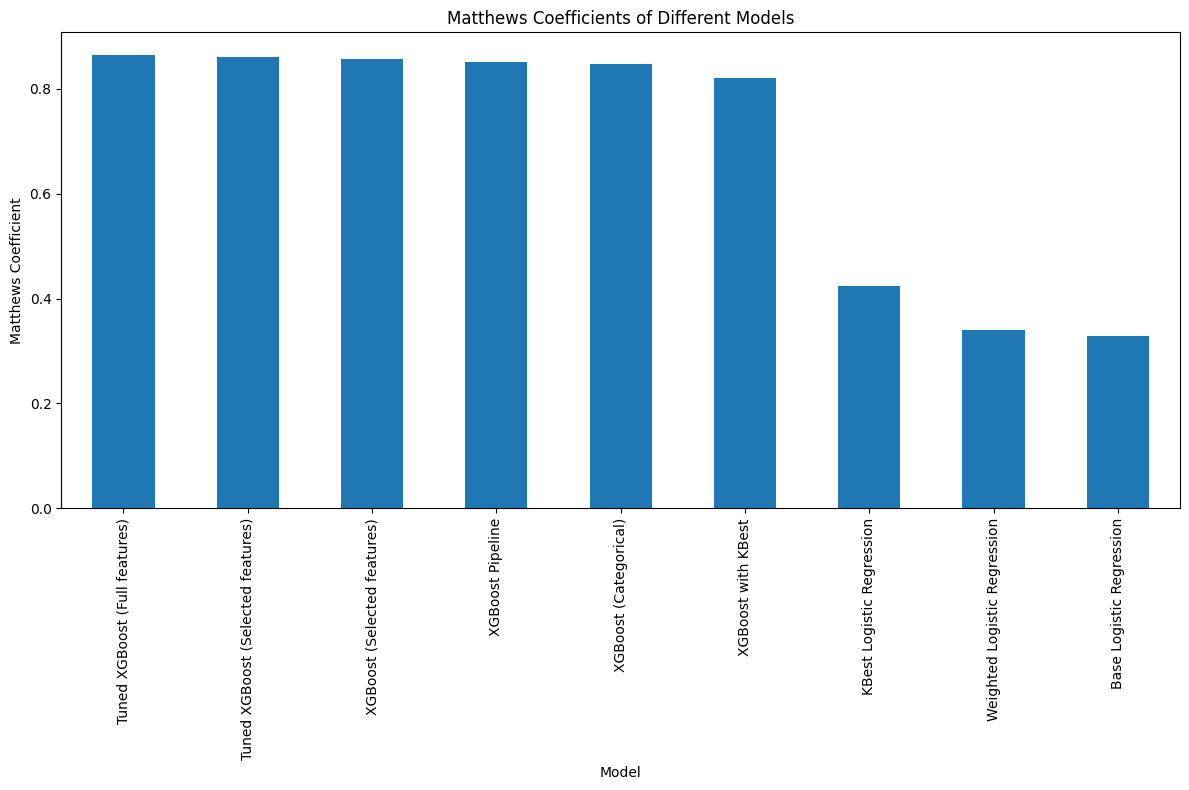

In [70]:
# Models trained on the full feature set (X_train), to be tested with X_test
models_full_features = {
    "Base Logistic Regression": base_log,
    "Weighted Logistic Regression": weight_log,
    "KBest Logistic Regression": kbest_log,
    "XGBoost Pipeline": xgboost_pipeline,
    "XGBoost with KBest": kbest_xgb,
    "XGBoost (Categorical)": xgb_cat,
    "Tuned XGBoost (Full features)": best_xgb_model # From cell 8bf4e545, tuned on X_train
}

# Models trained on the best selected features (X_trainb), to be tested with X_testb
models_best_features = {
    "XGBoost (Selected features)": xgb_bestf, # Trained on X_trainb
    "Tuned XGBoost (Selected features)": best_xgb_model_b # From cell 4ggfULrZnRkc, tuned on X_trainb
}

matt_co = []
model_names = []

# Evaluate models with full features
for name, model in models_full_features.items():
    y_pred = model.predict(X_test)
    coeff = matthews_corrcoef(y_test, y_pred)
    matt_co.append(coeff)
    model_names.append(name)

# Evaluate models with best features
for name, model in models_best_features.items():
    y_pred = model.predict(X_testb)
    coeff = matthews_corrcoef(y_testb, y_pred)
    matt_co.append(coeff)
    model_names.append(name)

# Create a pandas Series for easier sorting and plotting
model_matts = pd.Series(matt_co, index=model_names).sort_values(ascending=False)

# Plotting Matthews Coefficients
plt.figure(figsize=(12, 8))
model_matts.plot(kind='bar')
plt.title('Matthews Coefficients of Different Models')
plt.ylabel('Matthews Coefficient')
plt.xlabel('Model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# Final Results

In [74]:
model_matts

,0
Tuned XGBoost (Full features),0.864180
Tuned XGBoost (Selected features),0.861017
XGBoost (Selected features),0.855610
XGBoost Pipeline,0.850372
XGBoost (Categorical),0.846308
XGBoost with KBest,0.819987
KBest Logistic Regression,0.423349
Weighted Logistic Regression,0.339346
Base Logistic Regression,0.327626
